In [ ]:
import numpy as np
import pickle
import os
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
from matplotlib import patches

from ipywidgets.widgets import Dropdown, IntSlider
from ipywidgets import interact

In [ ]:
parent_dir = './'

all_action_phase = []
all_rewards = []


for i in tqdm(range(5)):
    datafile = 'nsp_sparse_data_' + str(i+1) + '_rl_opts.pkl'
    data_path = os.path.join(parent_dir, datafile)
    
    data_dict = dict()
    with open(data_path, 'rb') as file:
        load_data = pickle.load(file)

    # target_dict = load_data['target']
    # all_targets.append(target_dict)
    reward_dict = load_data['reward_value']
    all_rewards.append(reward_dict)
    action_phase = load_data['action_phase_data']
    all_action_phase.append(action_phase)

    data_dict['action_phase_data'] = action_phase
    data_dict['rewards'] = reward_dict

    name = 'filtered_nsp_sparse_data_' + str(i+1)
    chkpoint_file = os.path.join(parent_dir , str(name) + '_rl_opts.pkl')
    with open(chkpoint_file, 'wb') as f:
        pickle.dump(data_dict, f)

  0%|          | 0/5 [00:00<?, ?it/s]

### Reward and Phase fraction

In [ ]:
def moving_avg(data, window = 10):
    window = window  # moving average window size
    moving_avg = np.convolve(data, np.ones(window)/window, mode='valid')
    return moving_avg

def plot_phase_frac(data_ind):
    N_eps = 2000

    phase_frac = []
    reward_val = []
    mean_rewards = []
    for i in range(0, N_eps):
        phases = np.array(all_action_phase[data_ind]['epi_' + str(i)])[:-1,1]
        rewards = np.array(all_rewards[data_ind]['epi_' + str(i)])

        actv_phase_fraction = (phases.sum()/phases.shape[0])
        pasv_phase_fraction = 1 - (phases.sum()/phases.shape[0])

        reward_val.append(rewards)
        mean_rewards.append(np.mean(reward_val[-1]))


        phase_frac.append([pasv_phase_fraction, 
                       actv_phase_fraction])
    
    phase_frac = np.array(phase_frac)
    mean_rewards = np.array(mean_rewards)

    plt.figure(figsize=(11,5))

    ## Plot rewards
    plt.subplot(121)
    plt.plot(moving_avg(mean_rewards))
    plt.ylim(0, 0.015)
    plt.xlabel('Episode')
    plt.ylabel('Moving Average of Mean Reward')
    # plt.title(f'Moving Average (window={window}) of Mean Rewards per Episode')
    plt.ylim(0.3e-3, 1.5e-2)

    ## Plot Phase Fraction
    plt.subplot(122)
    plt.plot(phase_frac[:,0], label = 'Passive', alpha = 0.2)
    plt.plot(moving_avg(phase_frac[:,0]), c = 'C0', alpha = 0.8)

    plt.plot(phase_frac[:,1], label = 'Active', alpha = 0.2)
    plt.plot(moving_avg(phase_frac[:,1]), c = 'C1', alpha = 0.8)
    plt.xlabel('Episode')
    plt.ylabel('Fraction')
    plt.ylim(0.25,0.75)
    plt.legend()


interact(plot_phase_frac, data_ind = Dropdown(options=[0, 1, 2, 3, 4]))

interactive(children=(Dropdown(description='data_ind', options=(0, 1, 2, 3, 4), value=0), Output()), _dom_clas…

<function __main__.plot_phase_frac(data_ind)>

#### Get Mean

In [ ]:
N_eps = 2000

pasv_frac_stack = np.zeros((5, N_eps))
actv_frac_stack = np.zeros_like(pasv_frac_stack)
reward_stack = np.zeros_like(actv_frac_stack)

for data_ind in range(5):
    phase_frac = []
    reward_val = []
    mean_rewards = []
    for i in range(0, N_eps):
        phases = np.array(all_action_phase[data_ind]['epi_' + str(i)])[:-1,1]
        rewards = np.array(all_rewards[data_ind]['epi_' + str(i)])

        actv_phase_fraction = (phases.sum()/phases.shape[0])
        pasv_phase_fraction = 1 - (phases.sum()/phases.shape[0])

        reward_val.append(rewards)
        mean_rewards.append(np.mean(reward_val[-1]))


        phase_frac.append([pasv_phase_fraction, 
                       actv_phase_fraction])
    
    phase_frac = np.array(phase_frac)

    pasv_frac_stack[data_ind] = phase_frac[:,0]
    actv_frac_stack[data_ind] = phase_frac[:,1]
    reward_stack[data_ind] = np.array(mean_rewards)

rewards_mean = reward_stack.mean(axis=0)
rewards_std = reward_stack.std(axis=0)

pasv_frac_mean = pasv_frac_stack.mean(axis=0)
pasv_frac_std = pasv_frac_stack.std(axis=0)

actv_frac_mean = actv_frac_stack.mean(axis=0)
actv_frac_std = actv_frac_stack.std(axis=0)


<matplotlib.legend.Legend>

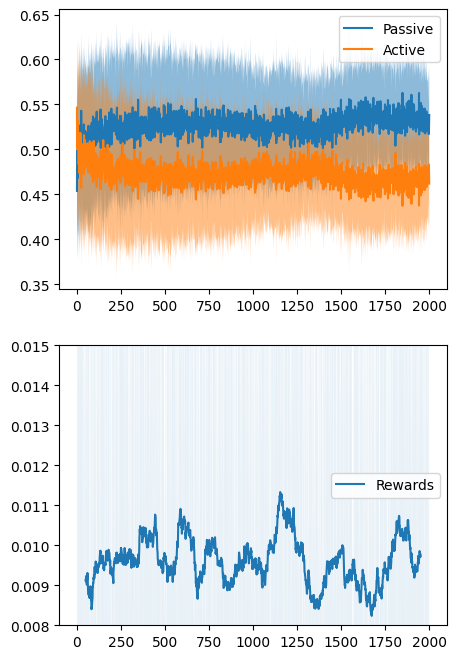

In [ ]:
plt.figure(figsize=(5,8))
plt.subplot(211)
plt.plot(np.arange(2000), pasv_frac_mean, label = 'Passive')
plt.fill_between(np.arange(2000), pasv_frac_mean-pasv_frac_std, pasv_frac_mean+pasv_frac_std, alpha = 0.5)

plt.plot(np.arange(2000), actv_frac_mean, label = 'Active')
plt.fill_between(np.arange(2000), actv_frac_mean-actv_frac_std, actv_frac_mean+actv_frac_std, alpha = 0.5)
plt.legend()

plt.subplot(212)
win = 100
plt.plot(moving_avg(np.arange(2000), window = win), moving_avg(rewards_mean, window=win), label = 'Rewards')
plt.fill_between(np.arange(2000), rewards_mean-rewards_std, rewards_mean+rewards_std, alpha = 0.1)
plt.setp(plt.gca(), ylim=(8e-3, 1.5e-2))
plt.legend()

### MFPT

In [ ]:
def compute_mfpt(data_ind, verbose=True):
    """
    Compute MFPT (Mean First Passage Time) statistics from a reward pkl file.
    
    The pkl file should have structure:
        {epi_0: [0,0,1,0,...], epi_1: [...], ...}
    where 1 = reward (target found), 0 = no reward at that timestep.

    Returns a dict with:
        - iri_all      : all inter-reward intervals (steps between consecutive rewards)
        - fpt_all      : first passage times (steps to first reward per episode)
        - ep_mfpt      : mean IRI per episode (nan if < 2 rewards)
        - mfpt_global  : global mean IRI across all episodes/runs
        - fpt_mean     : mean FPT across episodes
        - zero_reward_frac : fraction of episodes with no reward
        - n_episodes   : total number of episodes
    """

    data = all_rewards[data_ind]
    n_episodes = 2000
    iri_all    = []   # pooled inter-reward intervals
    fpt_all    = []   # first passage time per episode
    ep_mfpt    = []   # mean IRI per episode
    n_zero_rew = 0

    for ep_i in range(n_episodes):
        rv = np.array(data[f'epi_{ep_i}'], dtype=int)
        reward_times = np.where(rv == 1)[0]
        n_rewards = len(reward_times)

        if n_rewards == 0:
            # No reward in this episode — use episode length as proxy FPT
            fpt_all.append(len(rv))
            ep_mfpt.append(np.nan)
            n_zero_rew += 1

        elif n_rewards == 1:
            fpt_all.append(int(reward_times[0]))
            ep_mfpt.append(np.nan)   # need at least 2 rewards for an IRI

        else:
            fpt_all.append(int(reward_times[0]))
            intervals = np.diff(reward_times)  # IRI = gaps between successive rewards
            iri_all.extend(intervals.tolist())
            ep_mfpt.append(float(intervals.mean()))

    iri_all = np.array(iri_all)
    fpt_all = np.array(fpt_all)
    ep_mfpt = np.array(ep_mfpt)

    results = {
        'iri_all'           : iri_all,
        'fpt_all'           : fpt_all,
        'ep_mfpt'           : ep_mfpt,
        'mfpt_global'       : float(np.mean(iri_all)) if len(iri_all) > 0 else np.nan,
        'iri_median'        : float(np.median(iri_all)) if len(iri_all) > 0 else np.nan,
        'iri_std'           : float(np.std(iri_all)) if len(iri_all) > 0 else np.nan,
        'fpt_mean'          : float(np.nanmean(fpt_all)),
        'zero_reward_frac'  : n_zero_rew / n_episodes,
        'n_episodes'        : n_episodes,
    }

    if verbose:
        print(f"Episodes     : {n_episodes}  |  Zero-reward: {n_zero_rew} ({100*results['zero_reward_frac']:.1f}%)")
        print(f"MFPT (IRI mean)  : {results['mfpt_global']:.2f} steps")
        print(f"IRI median   : {results['iri_median']:.1f} steps")
        print(f"IRI std      : {results['iri_std']:.2f} steps")
        print(f"FPT mean     : {results['fpt_mean']:.2f} steps")
        print(f"Tail heaviness (mean/median): {results['mfpt_global']/results['iri_median']:.2f}")
        print()

    return results

In [ ]:
res = compute_mfpt(2)

Episodes     : 2000  |  Zero-reward: 950 (47.5%)
MFPT (IRI mean)  : 22.69 steps
IRI median   : 5.0 steps
IRI std      : 71.96 steps
FPT mean     : 215.25 steps
Tail heaviness (mean/median): 4.54



[0.0, 150.0, Text(0.5, 1.0, 'MFPT Distribution')]

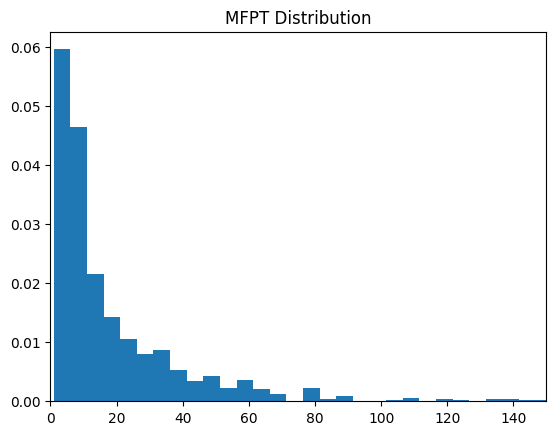

In [ ]:
plt.hist(res['ep_mfpt'], bins = 200, density =True)
plt.setp(plt.gca(), xlim=(0, 150), title='MFPT Distribution')

# plt.xscale('log')
# plt.yscale('log')

### Check H Matrix

Text(0.5, 0, 'Counter value')

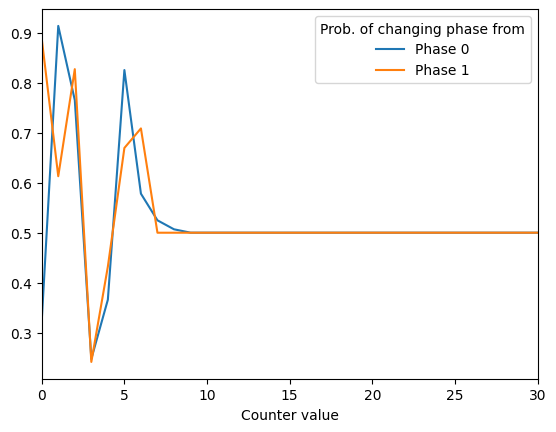

In [ ]:
# Now we get the probability of each action by normalizing the h_matrix
h_matrix = load_data['matrix']['epi_1999'][0]
probs = h_matrix / h_matrix.sum(axis=0)

prob_change_phase0 = probs[1, ::2]
prob_change_phase1 = probs[1, 1::2]

# These two objects must have same length
assert prob_change_phase0.shape == prob_change_phase1.shape


# And now we can e.g. plot them as a function of the counter

plt.plot(np.arange(500), prob_change_phase0, label = 'Phase 0')
plt.plot(np.arange(500), prob_change_phase1, label = 'Phase 1')
plt.setp(plt.gca(), xlim=(0,30))
plt.legend(title = 'Prob. of changing phase from')
plt.xlabel('Counter value')
# plt.title (f'gamma = {gamma}, eta = {eta:.2f}', fontdict={'fontsize':18})

### Make target Distribution

In [ ]:
load_data.keys()

dict_keys(['trajectories', 'displacements', 'trajectories_1', 'target', 'action_phase_data', 'reward_value', 'epi_lengths', 'matrix', 'epi_key', 'chkpoint_dir'])

In [ ]:
epi_lens = []
epi_rewards =[]
for i in range(2000):
    epi_lens.append(load_data['epi_lengths']['epi_'+str(i)][0])
    epi_rewards.append(np.array(load_data['reward_value']['epi_'+str(i)]).sum())
epi_lens = np.array(epi_lens)
epi_rewards = np.array(epi_rewards)
np.argwhere(epi_rewards==epi_rewards.max()), epi_lens[949]

(array([[949]]), np.int64(2000))

[0.0,
 75.0,
 0.0,
 75.0,
 Text(0.5, 1.0, 'Cumulative Target Distribution- Single Episode')]

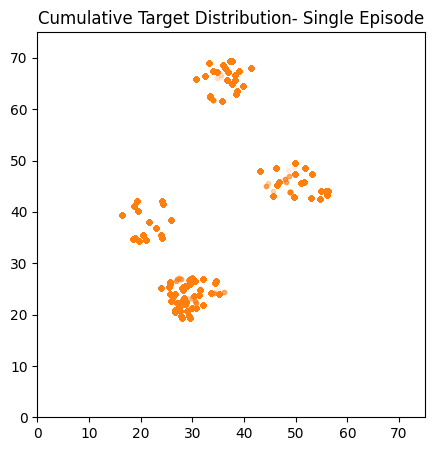

In [ ]:
plt.figure(figsize=(5,5))

max_ind = 949
for i in range(2000):
    target_positions = load_data['target']['epi_'+str(max_ind)][i]

    plt.plot(target_positions[:,0], target_positions[:,1], '.', color = 'C1', alpha=0.1)
    # for i in range(target_positions.shape[0]):
    #     circle = patches.Circle((target_positions[i,0],target_positions[i,1]), radius=1, facecolor='C1', alpha =1) ###
    #     plt.gca().add_patch(circle)
plt.setp(plt.gca(), xlim= (0,75), ylim=(0,75), title='Cumulative Target Distribution- Single Episode')
